In [76]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import anndata as ad
import gc
from sklearn.preprocessing import QuantileTransformer
from tqdm import tqdm
from sklearn.neighbors import KDTree
from scipy.spatial import cKDTree

from pythonimc import assembling, compensation, convert_to_fcs, merging, plotting, scdata, mcd_preprocessing
from pythonimc import scneighbors, segmentation, tissuezones3, polarity, phenotyping
import glasbey

In [77]:
# ── CONFIG — edit once per machine, then leave alone ────────────────────────
from pathlib import Path

# Détecte automatiquement le dossier du notebook (fonctionne dans VS Code et JupyterLab)
try:
    base_dir = str(Path(__vsc_ipynb_file__).parent)  # type: ignore[name-defined]  # VS Code
except NameError:
    base_dir = str(Path().resolve())                  # JupyterLab / Jupyter classic

data_dir = base_dir
ref_dir  = base_dir

print(f'base_dir → {base_dir}')
print('img/ contient :', list(Path(base_dir, 'img').glob('*.tiff')) if Path(base_dir, 'img').exists() else 'dossier img/ absent')
# ─────────────────────────────────────────────────────────────────────────────

base_dir → /Users/osmanrittano/Desktop/Machine Learning/BriceLab/stablVMax/PythonIMC/oscc
img/ contient : dossier img/ absent


# Preprocessing

## MCD conversion

1. Convert MCD to TIFF: 
    - base_dir needs a folder "raw" with MCD files. 
    - choose HPF (hot pixel filter) threshold
2. Create panel from MCD files

In [78]:
mcd_preprocessing.convert_mcd_to_tiff(base_dir, hpf=50)
mcd_preprocessing.create_panel_csv(base_dir)

Found 1 MCD file(s).
Saved /Users/osmanrittano/Desktop/Machine Learning/BriceLab/stablVMax/PythonIMC/oscc/img/001.tiff
Saved /Users/osmanrittano/Desktop/Machine Learning/BriceLab/stablVMax/PythonIMC/oscc/img/002.tiff
Saved /Users/osmanrittano/Desktop/Machine Learning/BriceLab/stablVMax/PythonIMC/oscc/img/003.tiff
Found 1 MCD files.
Saved panel to: /Users/osmanrittano/Desktop/Machine Learning/BriceLab/stablVMax/PythonIMC/oscc/panel.csv


,index,channel,marker,name
0,0,In113,None,CD15
1,1,In115,None,Podoplanin
2,2,Ce140,None,Vimentin
3,3,Pr141,None,aSMA
4,4,Nd142,None,CD206
5,5,Nd143,None,CD45RA
6,6,Nd144,None,CD14
7,7,Nd145,None,CD209
8,8,Nd146,None,CD16
9,9,Sm147,None,CD163


## Project-specific adjustments

In [79]:
# Panel OC26 — vérification (pas de correction de noms nécessaire pour ce dataset)
panel = pd.read_csv(os.path.join(base_dir, 'panel.csv'))
print(panel[['index','channel','name']].to_string())

    index channel            name
0       0   In113            CD15
1       1   In115      Podoplanin
2       2   Ce140        Vimentin
3       3   Pr141            aSMA
4       4   Nd142           CD206
5       5   Nd143          CD45RA
6       6   Nd144            CD14
7       7   Nd145           CD209
8       8   Nd146            CD16
9       9   Sm147           CD163
10     10   Nd148  Pancytokeratin
11     11   Sm149           CD11b
12     12   Nd150            CD86
13     13   Eu151            pp38
14     14   Sm152            CD45
15     15   Eu153          pSTAT1
16     16   Sm154          pSTAT3
17     17   Gd155           FoxP3
18     18   Gd156             CD4
19     19   Gd157            CD36
20     20   Gd158      E-Cadherin
21     21   Tb159            CD68
22     22   Gd160            CD31
23     23   Dy161            CD20
24     24   Dy162            CD8a
25     25   Dy163            VEGF
26     26   Dy164             CD3
27     27   Ho165           pCREB
28     28   Er

In [80]:
# Stitching : non applicable pour OC26 (pas d'acquisitions splitées).
# Cette cellule est à utiliser uniquement si une ROI a été acquise en deux morceaux.

# Image compensation

In [81]:
# Compensation spectrale : skippée pour OC26 (pas de spillovermatrix.csv disponible).
# La segmentation lira directement depuis img/ au lieu de img_comp/.
# Pour activer la compensation : fournir un spillovermatrix.csv dans base_dir
# et décommenter :
# compensation.batch_compensate_images(base_dir, spillover_filename='spillovermatrix.csv',
#                                       overwrite=False, backend='loky')

# Segmentation

## Segmentation (Mesmer)

Mesmer est un modèle entraîné spécifiquement sur des images de tissus multiplexés (IMC).  
L'inférence se fait via **ONNX Runtime** — aucun TensorFlow requis, fonctionne sur Intel et M1/M2.  
**Kernel requis : `Python (pythonimc)`** (env principal)

La cellule ci-dessous génère `mesmer.onnx` automatiquement sur Intel, ou affiche les instructions pour M1/M2.

In [82]:
# ── Conversion Mesmer → ONNX (une seule fois) ────────────────────────────────
# Ce bloc génère models/mesmer.onnx dans le repo PythonIMC.
#   • Intel Mac : la conversion se lance automatiquement si install.sh a été exécuté.
#   • M1/M2     : impossible de convertir ici — récupère models/mesmer.onnx auprès d'un
#                 collègue Intel ou depuis le serveur du labo.
#
# Si models/mesmer.onnx existe déjà, cette cellule ne fait rien.

import subprocess, os, platform

REPO_ROOT = os.path.dirname(base_dir)
ONNX_PATH = os.path.join(REPO_ROOT, "models", "mesmer.onnx")
SCRIPT_PATH = os.path.join(REPO_ROOT, "convert_mesmer_to_onnx.py")

if os.path.exists(ONNX_PATH):
    size_mb = os.path.getsize(ONNX_PATH) / 1e6
    print(f"models/mesmer.onnx déjà présent ({size_mb:.0f} MB) — rien à faire.")
elif platform.machine() == "arm64":
    print("Machine M1/M2 détectée.")
    print("La conversion nécessite TensorFlow (Intel uniquement).")
    print(f"Place mesmer.onnx ici : {ONNX_PATH}")
else:
    mesmer_py = None
    for candidate in [
        os.path.expanduser("~/miniconda3/envs/pythonimc-mesmer/bin/python"),
        os.path.expanduser("~/anaconda3/envs/pythonimc-mesmer/bin/python"),
        "/opt/miniconda3/envs/pythonimc-mesmer/bin/python",
        "/opt/anaconda3/envs/pythonimc-mesmer/bin/python",
    ]:
        if os.path.exists(candidate):
            mesmer_py = candidate
            break

    if mesmer_py is None:
        print("Env pythonimc-mesmer introuvable.")
        print("Lance d'abord : chmod +x install.sh && ./install.sh")
    else:
        print("Conversion en cours (2-3 min)...")
        os.makedirs(os.path.join(REPO_ROOT, "models"), exist_ok=True)
        result = subprocess.run(
            [mesmer_py, SCRIPT_PATH, "--output", ONNX_PATH],
            capture_output=True, text=True
        )
        if result.returncode == 0:
            print(result.stdout)
        else:
            print("Erreur lors de la conversion :")
            print(result.stderr[-2000:])


models/mesmer.onnx déjà présent (104 MB) — rien à faire.


In [83]:
# Segmentation whole-cell sur OC26 via ONNX (pas besoin de TensorFlow).
# Canaux : DNA1 (nucléaire) + Pancytokeratin + CD45 (membrane/cytoplasme).
# input_folder='img' car on a sauté la compensation.
#
# Pré-requis : mesmer.onnx dans ~/.keras/models/
#   Générer avec : conda activate pythonimc-mesmer && python convert_mesmer_to_onnx.py

segmentation.segment_imgs_mesmer_onnx(
    base_dir=base_dir,
    input_folder='img',
    output_folder='masks_onnx',
    markers=['DNA1'],
    membrane_markers=['Pancytokeratin', 'CD45'],
    postprocess_kwargs={
        'maxima_threshold': 0.075,
        'interior_threshold': 0.2,
        'interior_smooth': 2,
        'small_objects_threshold': 10,
    },
    image_mpp=0.5,
    overwrite=False,
)

Loading ONNX model from /Users/osmanrittano/Desktop/Machine Learning/BriceLab/stablVMax/PythonIMC/models/mesmer.onnx ...
Found 3 image(s) in /Users/osmanrittano/Desktop/Machine Learning/BriceLab/stablVMax/PythonIMC/oscc/img
Processing: /Users/osmanrittano/Desktop/Machine Learning/BriceLab/stablVMax/PythonIMC/oscc/img/002.tiff
Processing: /Users/osmanrittano/Desktop/Machine Learning/BriceLab/stablVMax/PythonIMC/oscc/img/002.tiff
Processed 002.tiff: 2438 cells detected, saved to /Users/osmanrittano/Desktop/Machine Learning/BriceLab/stablVMax/PythonIMC/oscc/masks_onnx/002.tiff
Processing: /Users/osmanrittano/Desktop/Machine Learning/BriceLab/stablVMax/PythonIMC/oscc/img/001.tiff
Processing: /Users/osmanrittano/Desktop/Machine Learning/BriceLab/stablVMax/PythonIMC/oscc/img/001.tiff
Processed 001.tiff: 2610 cells detected, saved to /Users/osmanrittano/Desktop/Machine Learning/BriceLab/stablVMax/PythonIMC/oscc/masks_onnx/001.tiff
Processing: /Users/osmanrittano/Desktop/Machine Learning/Brice

## Additional segmentation runs

In [84]:
# Segmentation additionnelle (ex : masque nucléaire séparé) — optionnelle.
# Pour OC26, un seul run de segmentation suffit pour un premier test.
# Décommenter si nécessaire :

# segmentation.segment_imgs_mesmer_onnx(
#     base_dir=base_dir,
#     input_folder='img',
#     output_folder='masks_nuclear_mesmer',
#     markers=['DNA1'],
#     overwrite=False,
# )

## Merging masks

In [85]:
# Merge de masques — non applicable si on n'a qu'un seul run de segmentation.
# Pour OC26 on utilise directement masks_onnx/ comme masks_merged.
import shutil, os
src = os.path.join(base_dir, 'masks_onnx')
dst = os.path.join(base_dir, 'masks_merged')
if os.path.exists(src) and not os.path.exists(dst):
    shutil.copytree(src, dst)
    print(f'masks_onnx/ copié dans masks_merged/')
else:
    print(f'masks_merged/ existe déjà ou masks_onnx/ absent.')

masks_onnx/ copié dans masks_merged/


# Tissue zones

In [86]:
tissuezones3.batch_generate_compartment_masks(
    base_dir=base_dir,
    tissue_channel=[0, 1],
    tumor_channel=10,          # index 10 = Pancytokeratin (marqueur tumeur)
    muscle_channel=3,          # index 3 = aSMA (smooth muscle)
    overwrite=False,
    plot=False,
    img_folder='img',
    mask_folder='masks_merged',
)

Skipping existing file: 003.tiff
Skipping existing file: 001.tiff
Skipping existing file: 002.tiff


# Single-cell data generation

In [87]:
scdata.create_intensities_files(
    base_dir,
    image_folder='img',
    masks_folder='masks_merged',
    aggregation='mean'
)

scdata.create_regionprops_files(
    base_dir,
    image_folder='img',
    masks_folder='masks_merged',
    compartment_masks_folder='masks_compartments'
)

scneighbors.create_neighbors_files(
    base_dir,
    masks_folder='masks_merged',
    neighbors_folder='neighbors',
    neighborhood_type='EUCLIDEAN_BORDER_DISTANCE',
    dmax=50.0,
    kmax=30
)

Found 3 image–mask pairs
Saved intensities: 003.csv
Saved intensities: 002.csv
Saved intensities: 001.csv
Missing compartment mask for 002.tiff, skipping zone assignment.
Saved regionprops: 002.csv
Missing compartment mask for 001.tiff, skipping zone assignment.
Saved regionprops: 001.csv
Missing compartment mask for 003.tiff, skipping zone assignment.
Saved regionprops: 003.csv
Saved neighbors: 003.csv
Saved neighbors: 001.csv
Saved neighbors: 002.csv


# FCS file conversion

In [88]:
convert_to_fcs.batch_convert_to_fcs(base_dir)

✅ Saved FCS: /Users/osmanrittano/Desktop/Machine Learning/BriceLab/stablVMax/PythonIMC/oscc/fcs_files/001.fcs
✅ Saved FCS: /Users/osmanrittano/Desktop/Machine Learning/BriceLab/stablVMax/PythonIMC/oscc/fcs_files/003.fcs
✅ Saved FCS: /Users/osmanrittano/Desktop/Machine Learning/BriceLab/stablVMax/PythonIMC/oscc/fcs_files/002.fcs


# Assembling dataset

In [89]:
data = assembling.assemble_anndata(base_dir, add_polarity=False)

# Sauvegarder
data.write(os.path.join(data_dir, 'OC26_data_mesmer.h5ad'))
print(data)

Loading intensity data...


Reading intensities: 100%|██████████| 3/3 [00:00<00:00, 19.86it/s]


AnnData object created successfully!
(7799, 41)
Loading regionprops data...


Reading regionprops: 100%|██████████| 3/3 [00:00<00:00, 100.71it/s]


Regionprops data merged successfully!
AnnData object with n_obs × n_vars = 7799 × 41
    obs: 'Object', 'Image', 'Area', 'Centroid-0', 'Centroid-1', 'Axis_major_length', 'Axis_minor_length', 'Eccentricity', 'Orientation'
    var: 'channel_marker', 'marker', 'channel'
    layers: 'counts'


In [90]:
_h5ad_path = os.path.join(data_dir, 'OC26_data_mesmer.h5ad')
if os.path.exists(_h5ad_path):
    data = ad.read_h5ad(_h5ad_path)
elif 'data' not in dir():
    raise FileNotFoundError(
        f"OC26_data_mesmer.h5ad introuvable ({_h5ad_path}).\n"
        "Lance d'abord la cellule précédente (assemble_anndata)."
    )
# sinon : data est déjà en mémoire depuis la cellule précédente

# TMA : dérivé du premier caractère du nom d'image (pour le batch correction)
data.obs["TMA"] = data.obs["Image"].str[0]

# Exclure le fond si les tissue zones ont été générées
if "Zone" in data.obs.columns:
    data = data[data.obs["Zone"] != "Background"].copy()
    data.obs["Region"] = data.obs["Zone"].str.split("_").str[0]
else:
    data.obs["Region"] = "Unknown"

gc.collect()

12

# Batch correction

In [91]:
# Use arcsinh-transformed signal as input
X_raw = np.arcsinh(data.layers["counts"] - 1 ).astype(np.float32)
batches = data.obs["TMA"].values
markers = data.var_names

corrected = np.zeros_like(X_raw, dtype=np.float32)
unique_batches = np.unique(batches)

nq = 100  # number of quantiles (50–200 is fine)

for i, marker in enumerate(tqdm(markers, desc="Quantile normalizing per marker")):
    x = X_raw[:, i]
    corrected_marker = np.zeros_like(x)
    
    # --- 1. Fit reference distribution (global across all batches) ---
    ref_qt = QuantileTransformer(
        output_distribution="uniform",
        n_quantiles=nq,
        random_state=42,
        subsample=1_000_000
    )
    ref_qt.fit(x.reshape(-1, 1))
    ref_vals = ref_qt.quantiles_.ravel()  # flatten to 1-D
    
    # target quantile grid (0..1)
    q_grid = np.linspace(0, 1, nq)
    
    # --- 2. Align each batch to the reference ---
    for b in unique_batches:
        mask = batches == b
        xb = x[mask]
        
        if xb.size < 10:
            # Skip tiny batches
            corrected_marker[mask] = xb
            continue
        
        qt_batch = QuantileTransformer(
            output_distribution="uniform",
            n_quantiles=min(nq, xb.size),
            random_state=42,
            subsample=min(len(xb), 500_000)
        )
        qt_batch.fit(xb.reshape(-1, 1))
        
        xb_uniform = qt_batch.transform(xb.reshape(-1, 1)).ravel()
        corrected_marker[mask] = np.interp(xb_uniform, q_grid, ref_vals)
    
    corrected[:, i] = corrected_marker

# Save the corrected matrix back into the AnnData object
data.layers["corrected"] = corrected
del corrected
del X_raw

Quantile normalizing per marker: 100%|██████████| 41/41 [00:00<00:00, 254.91it/s]


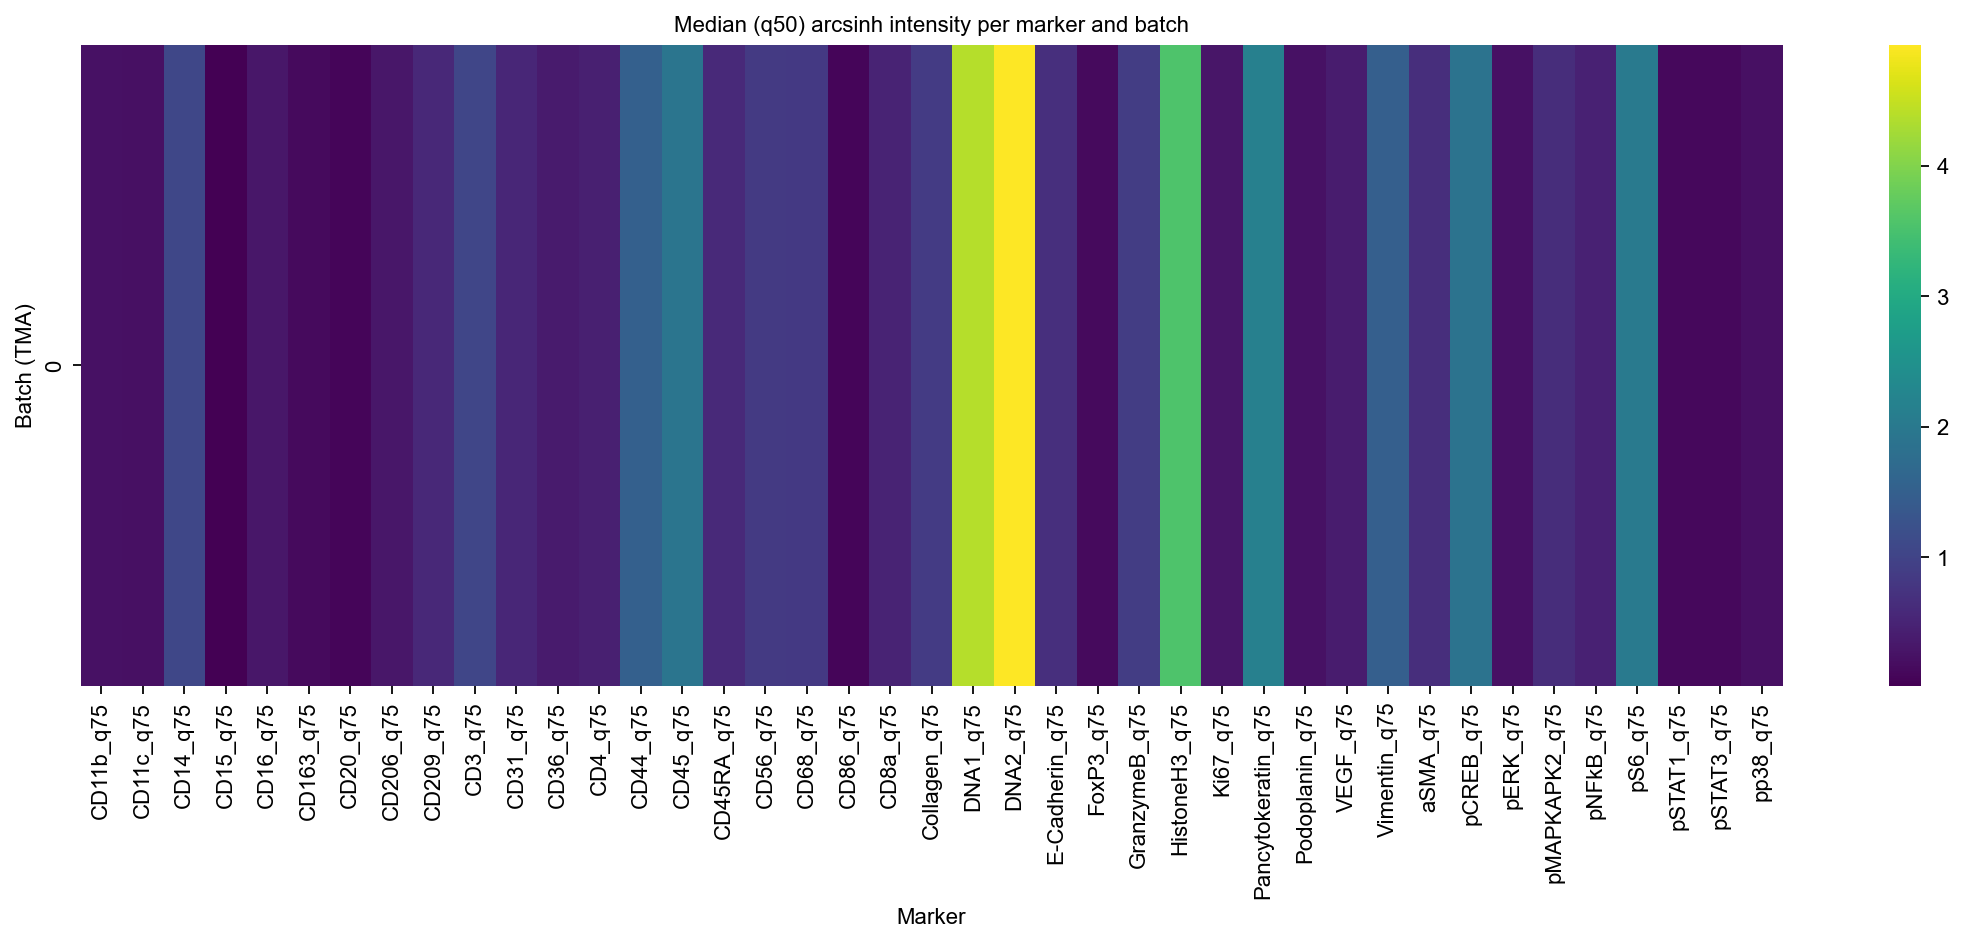

In [92]:
X = pd.DataFrame(
    np.arcsinh(data.layers["counts"]).astype(np.float32),
    columns=data.var_names,
    index=data.obs_names
)

batches = data.obs["TMA"]

# --- 2. Compute quantiles per batch and marker ---
quantiles = [0.05, 0.25, 0.5, 0.75, 0.95]

# Join the batch info
X["TMA"] = batches.values

# Compute quantiles per batch and marker
quantile_df = (
    X.groupby("TMA")
    .quantile(quantiles)
    .reset_index()
)

# The resulting index has two levels: 'TMA' and the quantile level
# We'll pivot to have markers × quantiles per batch
quantile_df = quantile_df.melt(
    id_vars=["TMA", "level_1"],
    var_name="Marker",
    value_name="Intensity"
)
quantile_df["Quantile"] = quantile_df["level_1"].map(lambda q: f"q{int(q*100)}")
quantile_df.drop(columns="level_1", inplace=True)

# --- 3. Optional: Pivot into a wide table for heatmap ---
pivot_df = (
    quantile_df.pivot_table(
        index="TMA",
        columns=["Marker", "Quantile"],
        values="Intensity"
    )
)

# Simplify multiindex columns for visualization
pivot_df.columns = [f"{marker}_{quantile}" for marker, quantile in pivot_df.columns]

# --- 4. Visualize median (q50) intensities per batch ---
median_cols = [c for c in pivot_df.columns if "_q75" in c]
plt.figure(figsize=(14, 6))
sns.heatmap(pivot_df[median_cols], cmap="viridis")
plt.title("Median (q50) arcsinh intensity per marker and batch")
plt.xlabel("Marker")
plt.ylabel("Batch (TMA)")
plt.tight_layout()
plt.show()

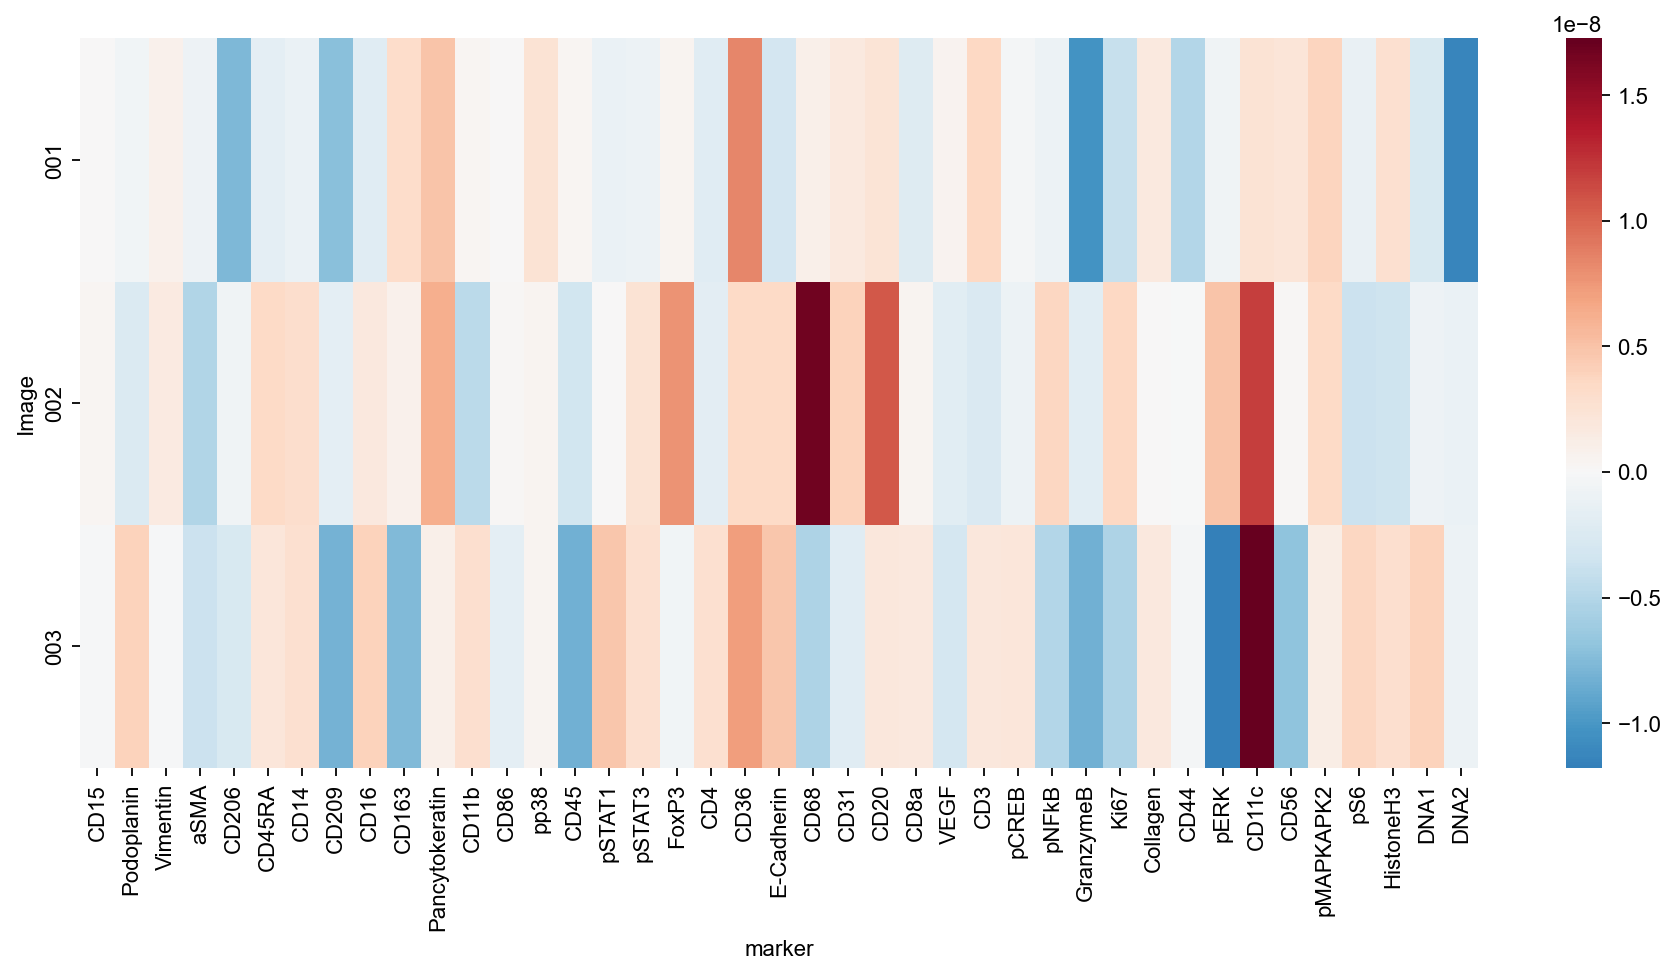

In [93]:
counts = np.arcsinh(data.layers["counts"] - 1)
corrected = data.layers["corrected"]

# Difference matrix
diff = corrected - counts  # shape (cells, markers)
df_diff = pd.DataFrame(diff, index=data.obs.index, columns=data.var.index)

# add Image column for grouping
df_diff["Image"] = data.obs["Image"].values

heatmap_data = df_diff.groupby("Image").mean()
heatmap_data = heatmap_data.astype(float)

plt.figure(figsize=(14,6))
sns.heatmap(
    heatmap_data,
    cmap="RdBu_r",        # diverging colormap
    center=0
)
plt.show()

# Phenotyping

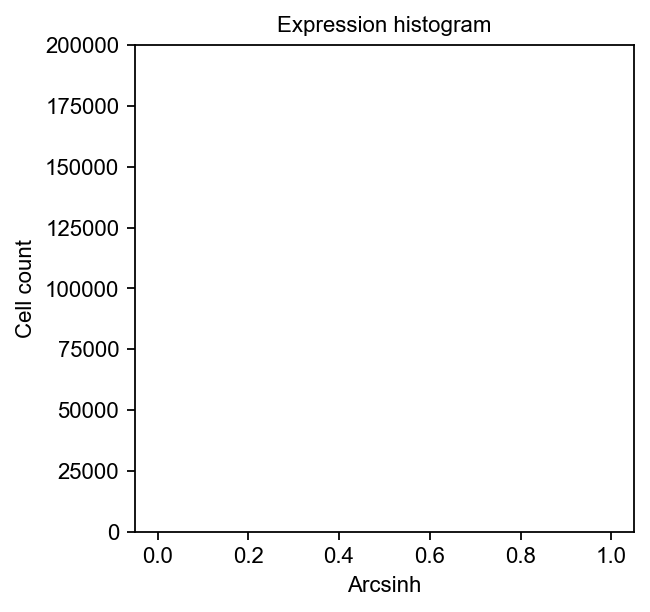

In [94]:
cd68_idx = data.var.index.get_loc("CD8a")
mask = data.obs['Region'] == "Tumor"
cd68_vals = np.arcsinh(data.layers['counts'][:, cd68_idx] - 1)[mask]
cd68_vals_c = data.layers['corrected'][:, cd68_idx][mask]

plt.hist(cd68_vals / cd68_vals.std(), bins=100, alpha=0.5)
plt.hist(cd68_vals_c / cd68_vals_c.std(), bins=100, alpha=0.5)
plt.ylim(0, 200_000)
plt.xlabel("Arcsinh")
plt.ylabel("Cell count")
plt.title("Expression histogram")
plt.show()

## Tumor subsetting

Setting: 

lr=0.0005, prior_std=0.3, max_epochs=400, patience=8, polarity=False, 113 epochs, 

Results: 

TumorNonproliferating    0.413678
TumorSOX9+               0.121837
TumorpMK2+               0.116865
CD8Tcells                0.110369
Granulocytes             0.072233
TumorKi67+               0.064336
TumorKi67+SOX9+          0.054136
CD4Tcells                0.030836
Bcells                   0.005253

In [95]:
import os as _os
_kt_path = _os.path.join(base_dir, "knowledgetables")
if not _os.path.isdir(_kt_path):
    print("Skipping phenotyping step: knowledgetables/ folder not found.")
    print("Add your dataset-specific .xlsx knowledge tables to:", _kt_path)
else:
    phenotyping.run_scyan(adata=data, 
                          knowledgetable="knowledgetable_tumor_new.xlsx", 
                          knowledgetable_dir="knowledgetables", 
                          base_dir=base_dir, 
                          batch_key="Image",
                          filter="Region",
                          filter_for="Tumor",
                          unassigned_label="TumorNonproliferating",
                          phenotype_level="Celltype",
                          prior_std=0.3,
                          polarity=False)


Skipping phenotyping step: knowledgetables/ folder not found.
Add your dataset-specific .xlsx knowledge tables to: /Users/osmanrittano/Desktop/Machine Learning/BriceLab/stablVMax/PythonIMC/oscc/knowledgetables


## Stroma subsetting

Settings: 

lr=0.0005, prior_std=0.4, max_epochs=400, patience=8, polarity=False, 131 epochs, 

Results:
Other                    0.187321
CD8Tcells                0.159827
CD4Tcells                0.123115
Granulocytes             0.089797
Capillary                0.087337
Bcells                   0.066582
Macrophages              0.055866
Arteriole                0.053131
Monocytes                0.046908
TumorNonproliferating    0.041357
FibroblastsTenC+         0.030246
SM                       0.029278
Lymphatics               0.026701
Nerve                    0.001860

In [96]:
import os as _os
_kt_path = _os.path.join(base_dir, "knowledgetables")
if not _os.path.isdir(_kt_path):
    print("Skipping phenotyping step: knowledgetables/ folder not found.")
    print("Add your dataset-specific .xlsx knowledge tables to:", _kt_path)
else:
    phenotyping.run_scyan(adata=data, 
                          knowledgetable="knowledgetable_stroma.xlsx", 
                          knowledgetable_dir="knowledgetables", 
                          base_dir=base_dir, 
                          batch_key="TMA",
                          filter="Region",
                          filter_for="Stroma",
                          unassigned_label="Other",
                          phenotype_level="Celltype",
                          prior_std=0.4,
                          polarity=False)


Skipping phenotyping step: knowledgetables/ folder not found.
Add your dataset-specific .xlsx knowledge tables to: /Users/osmanrittano/Desktop/Machine Learning/BriceLab/stablVMax/PythonIMC/oscc/knowledgetables


## Muscle subsetting

Settings: 

lr=0.0005, prior_std=0.3, max_epochs=400, patience=8, polarity=True, 60 epoches

Results:

SM              0.848713
Capillary       0.074307
Granulocytes    0.025103
Macrophages     0.014928
Bcells          0.010080
Monocytes       0.007407

In [97]:
import os as _os
_kt_path = _os.path.join(base_dir, "knowledgetables")
if not _os.path.isdir(_kt_path):
    print("Skipping phenotyping step: knowledgetables/ folder not found.")
    print("Add your dataset-specific .xlsx knowledge tables to:", _kt_path)
else:
    phenotyping.run_scyan(adata=data, 
                          knowledgetable="knowledgetable_muscle_new.xlsx", 
                          knowledgetable_dir="knowledgetables", 
                          base_dir=base_dir, 
                          batch_key="Image", 
                          filter="Region",
                          filter_for="Muscle",
                          unassigned_label="Other",
                          phenotype_level="Celltype",
                          prior_std=0.26,
                          polarity=False)


Skipping phenotyping step: knowledgetables/ folder not found.
Add your dataset-specific .xlsx knowledge tables to: /Users/osmanrittano/Desktop/Machine Learning/BriceLab/stablVMax/PythonIMC/oscc/knowledgetables


In [98]:
for col in data.obs.select_dtypes(include=["datetime64[ns]"]).columns:
    data.obs[col] = data.obs[col].dt.strftime("%Y-%m-%d")
data.write(os.path.join(data_dir, 'OC26_mesmer_annot1.h5ad'))

## CD4 T cell subsetting

Settings: prior_std=0.4, lr=0.00001, polarity=True, max_epochs=400, patience=8, 150 epochs

Results: 

CD4Tmemory    0.751599
CD4Tfh        0.109102
CD4Tnaive     0.100423
CD4Tregs      0.038858

In [99]:
_h5ad_annot1 = os.path.join(data_dir, 'OC26_mesmer_annot1.h5ad')
if os.path.exists(_h5ad_annot1):
    data = ad.read_h5ad(_h5ad_annot1)
elif 'data' not in dir():
    raise FileNotFoundError(
        f"OC26_mesmer_annot1.h5ad introuvable ({_h5ad_annot1}).\n"
        "Lance d'abord les cellules de phénotypage (jusqu'à la sauvegarde annot1).")
# sinon : data déjà en mémoire

In [100]:
import os as _os
_kt_path = _os.path.join(base_dir, "knowledgetables")
if not _os.path.isdir(_kt_path):
    print("Skipping phenotyping step: knowledgetables/ folder not found.")
    print("Add your dataset-specific .xlsx knowledge tables to:", _kt_path)
else:
    phenotyping.run_scyan(adata=data, 
                          knowledgetable="knowledgetable_CD4Tcells.xlsx", 
                          knowledgetable_dir="knowledgetables", 
                          base_dir=base_dir, 
                          batch_key="TMA", 
                          filter="Celltype",
                          filter_for="CD4Tcells",
                          unassigned_label="CD4Tmemory",
                          phenotype_level="Subtype",
                          prior_std=0.3,
                          polarity=False)


Skipping phenotyping step: knowledgetables/ folder not found.
Add your dataset-specific .xlsx knowledge tables to: /Users/osmanrittano/Desktop/Machine Learning/BriceLab/stablVMax/PythonIMC/oscc/knowledgetables


## CD8 T cell subsetting

Settings: lr=0.0005, prior_std=0.3, polarity=True, 32 epochs

Results:

CD8Tmemory     0.481928
CD8Teff        0.342798
CD8Tnaive      0.141382
CD8Ttrmlike    0.033469

In [101]:
import os as _os
_kt_path = _os.path.join(base_dir, "knowledgetables")
if not _os.path.isdir(_kt_path):
    print("Skipping phenotyping step: knowledgetables/ folder not found.")
    print("Add your dataset-specific .xlsx knowledge tables to:", _kt_path)
else:
    phenotyping.run_scyan(adata=data, 
                          knowledgetable="knowledgetable_CD8Tcells.xlsx", 
                          knowledgetable_dir="knowledgetables", 
                          base_dir=base_dir, 
                          batch_key="Image", 
                          filter="Celltype",
                          filter_for="CD8Tcells",
                          unassigned_label="CD8Tmemory",
                          phenotype_level="Subtype",
                          prior_std=0.3,
                          polarity=False)


Skipping phenotyping step: knowledgetables/ folder not found.
Add your dataset-specific .xlsx knowledge tables to: /Users/osmanrittano/Desktop/Machine Learning/BriceLab/stablVMax/PythonIMC/oscc/knowledgetables


## MacroMono subsetting

In [102]:
import os as _os
_kt_path = _os.path.join(base_dir, "knowledgetables")
if not _os.path.isdir(_kt_path):
    print("Skipping phenotyping step: knowledgetables/ folder not found.")
    print("Add your dataset-specific .xlsx knowledge tables to:", _kt_path)
else:
    phenotyping.run_scyan(adata=data, 
                          knowledgetable="knowledgetable_MacroMono.xlsx", 
                          knowledgetable_dir="knowledgetables", 
                          base_dir=base_dir, 
                          batch_key="TMA", 
                          filter="Celltype",
                          filter_for=["Macrophages", "Monocytes"],
                          unassigned_label="M1Macro",
                          phenotype_level="Subtype",
                          prior_std=0.5,
                          polarity=False)


Skipping phenotyping step: knowledgetables/ folder not found.
Add your dataset-specific .xlsx knowledge tables to: /Users/osmanrittano/Desktop/Machine Learning/BriceLab/stablVMax/PythonIMC/oscc/knowledgetables


In [103]:
if "Celltype" not in data.obs.columns or "Subtype" not in data.obs.columns:
    print("Skipping: Celltype/Subtype not found — phenotyping was skipped.")
else:
    # Ensure both are categorical
    data.obs["Celltype"] = data.obs["Celltype"].astype("category")
    data.obs["Subtype"] = data.obs["Subtype"].astype("category")

    # Add any missing categories from Celltype into Subtype
    missing_cats = [cat for cat in data.obs["Celltype"].cat.categories
                    if cat not in data.obs["Subtype"].cat.categories]
    if missing_cats:
        data.obs["Subtype"] = data.obs["Subtype"].cat.add_categories(missing_cats)

    # Fill only missing values in Subtype with string values from Celltype
    mask = data.obs["Subtype"].isna()
    data.obs.loc[mask, "Subtype"] = data.obs.loc[mask, "Celltype"].astype(str)

    # Clean unused categories
    data.obs["Subtype"] = data.obs["Subtype"].astype("category")
    data.obs["Subtype"] = data.obs["Subtype"].cat.remove_unused_categories()

Skipping: Celltype/Subtype not found — phenotyping was skipped.


In [104]:
data.write(os.path.join(data_dir, 'OC26_mesmer_annot2.h5ad'))

# Distance to the tumorborder

In [105]:
data = tissuezones3.calculate_distance_to_tumor(base_dir, data, columnname='Distance_to_tumor', overwrite=False)

Skipping calculate_distance_to_tumor: 'masks_compartments/' not found.
Run the tissue zones step first to generate compartment masks.


In [106]:
_h5ad_annot3 = os.path.join(data_dir, 'OC26_mesmer_annot3.h5ad')
for col in data.obs.columns:
    if pd.api.types.is_datetime64_any_dtype(data.obs[col]):
        data.obs[col] = data.obs[col].astype(str)
data.write(_h5ad_annot3)

In [107]:
_h5ad_annot3 = os.path.join(data_dir, 'OC26_mesmer_annot3.h5ad')
if os.path.exists(_h5ad_annot3):
    data = ad.read_h5ad(_h5ad_annot3)
elif 'data' not in dir():
    raise FileNotFoundError(
        f"OC26_mesmer_annot3.h5ad introuvable ({_h5ad_annot3}).\n"
        "Lance d'abord les cellules précédentes (phénotypage + distance).")
# sinon : data est déjà en mémoire

In [108]:
if 'Distance_to_tumor' not in data.obs.columns:
    print("Skipping: Distance_to_tumor manquant — lance d'abord calculate_distance_to_tumor.")
    sub = None
else:
    sub = data[
        # (data.obs['Neighboring_CD8Tnaive'] > 0) |
        # (data.obs['Neighboring_CD8Tmemory'] > 0) |
        # (data.obs['Neighboring_CD8Ttrmlike'] > 0) |
        # (data.obs['Neighboring_CD8Teff'] > 0)
        (data.obs['Distance_to_tumor'].between(-100, 100))
    ].copy()

In [109]:
if sub is None or 'Sector' not in sub.obs.columns or 'Subtype' not in sub.obs.columns:
    print("Skipping: Sector ou Subtype manquant dans sub.")
    freq_wide = None
else:
    # Count cells per Image, Sector, Subtype
    counts = (
        sub.obs
        .groupby(["Image", "Sector", "Subtype"])
        .size()
        .reset_index(name="Count")
    )

    # Compute total cells per image *and zone*
    total_per_zone = (
        counts
        .query('Subtype != "Other"')  # exclude unclassified cells
        .groupby(["Image", "Sector"])["Count"]
        .sum()
        .reset_index(name="Total_excl_Other")
    )

    # Merge totals (only affects the denominator)
    freq_df = counts.merge(total_per_zone, on=["Image", "Sector"], how="left")

    # Compute frequency only relative to classified cells
    freq_df["Frequency"] = freq_df["Count"] / freq_df["Total_excl_Other"] * 100

    # Pivot to wide table
    freq_wide = freq_df.pivot_table(
        index="Image",
        columns=["Subtype", "Sector"],
        values="Frequency",
        fill_value=0
    )

    # Flatten MultiIndex columns
    freq_wide.columns = [f"{subtype}_{sector}_freq" for subtype, sector in freq_wide.columns]
    print(freq_wide.shape)

Skipping: Sector ou Subtype manquant dans sub.


In [110]:
_outcome_cols = ['Casenumber', 'Recurrence_3yrs', 'Recurrence_5yrs', 'PFS']
if not all(c in data.obs.columns for c in _outcome_cols):
    print("Skipping: colonnes cliniques manquantes — lance d'abord assembling.add_metadata (Cell 99).")
    outcome_df = None
else:
    outcome_df = data.obs[['Image'] + _outcome_cols].drop_duplicates().set_index('Image')
    outcome_df.sort_index(inplace=True)

Skipping: colonnes cliniques manquantes — lance d'abord assembling.add_metadata (Cell 99).


In [111]:
if 'ImageCluster' not in data.obs.columns:
    print("Skipping: ImageCluster manquant — lance d'abord la cellule qui charge clustering.csv.")
    cluster_df = None
else:
    cluster_df = data.obs[['Image', 'ImageCluster']].drop_duplicates().set_index('Image')
    cluster_df = cluster_df.sort_index()

Skipping: ImageCluster manquant — lance d'abord la cellule qui charge clustering.csv.


In [112]:
if any(globals().get(v) is None for v in ['freq_wide','outcome_df','cluster_df']):
    print("Skipping: freq_wide, outcome_df ou cluster_df manquant.")
    X = None
    y = None
else:
    from scipy.stats import mannwhitneyu
    import pandas as pd
    
    # Align everything
    common_idx = freq_wide.index.intersection(outcome_df.index).intersection(cluster_df.index)
    X = freq_wide.loc[common_idx]
    y = outcome_df.loc[common_idx, 'Recurrence_3yrs'].dropna()
    clusters = cluster_df.loc[y.index]  # assuming cluster_df has a 'cluster' column
    X = X.loc[y.index]
    
    def get_pvals(X_sub, y_sub):
        results = {}
        for col in X_sub.columns:
            a = X_sub.loc[y_sub == 0, col]
            b = X_sub.loc[y_sub == 1, col]
            if len(a) < 3 or len(b) < 3:
                results[col] = None
                continue
            _, p = mannwhitneyu(a, b, alternative='two-sided')
            results[col] = p
        return results
    
    # Global
    pval_df = pd.DataFrame({'global': get_pvals(X, y)})
    
    # Per cluster - adjust column name as needed
    for cl in clusters['ImageCluster'].unique():
        idx = clusters[clusters['ImageCluster'] == cl].index
        pval_df[f'cluster_{cl}'] = get_pvals(X.loc[idx], y.loc[idx])
    
    print(pval_df)

Skipping: freq_wide, outcome_df ou cluster_df manquant.


In [113]:
if any(globals().get(v) is None for v in ['X','y','cluster_df','outcome_df']):
    print("Skipping: X, y, cluster_df ou outcome_df manquant — lance d'abord Cell 63.")
else:
    from xgboost import XGBClassifier
    from sklearn.model_selection import StratifiedGroupKFold
    from sklearn.metrics import roc_auc_score
    
    # Subset to cluster 1
    cl1_idx = cluster_df[cluster_df['ImageCluster'] == 3].index.intersection(y.index)
    X_cl1 = X.loc[cl1_idx]
    y_cl1 = y.loc[cl1_idx]
    groups = outcome_df.loc[cl1_idx, 'Casenumber']
    
    print(f"n={len(y_cl1)}, recurrence rate={y_cl1.mean():.2f}")
    
    # Model with L1 penalty (reg_alpha)
    model = XGBClassifier(
        reg_alpha=0.1,        # L1
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        eval_metric='logloss',
        random_state=42,
        nthread=1
    )
    
    print(cl1_idx)
    print(len(cl1_idx))
    
    # Group-stratified CV
    cv = StratifiedGroupKFold(n_splits=5)
    
    aucs = []
    for fold, (train_idx, test_idx) in enumerate(cv.split(X_cl1, y_cl1, groups=groups)):
        X_train, X_test = X_cl1.iloc[train_idx], X_cl1.iloc[test_idx]
        y_train, y_test = y_cl1.iloc[train_idx], y_cl1.iloc[test_idx]
        print(f"Fold {fold+1}: Train n={len(y_train)}, recurrence={y_train.mean():.2f} | Test n={len(y_test)}, recurrence={y_test.mean():.2f}")
        model.fit(X_train, y_train)
        y_pred = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_pred)
        aucs.append(auc)
        print(f"Fold {fold+1}: AUC={auc:.3f}, test n={len(y_test)}, recurrence={y_test.mean():.2f}")
    
    print(f"\nMean AUC: {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")

Skipping: X, y, cluster_df ou outcome_df manquant — lance d'abord Cell 63.


In [114]:
if not all(c in data.obs.columns for c in ['ImageCluster','Recurrence_3yrs','Celltype']):
    print("Skipping: ImageCluster, Recurrence_3yrs ou Celltype manquant.")
else:
    import numpy as np
    
    # ── 1. Select images ──────────────────────────────────────────────────────────
    mask = (data.obs["ImageCluster"] == 0)
    
    recur_images    = data.obs.loc[mask & (data.obs["Recurrence_3yrs"] == 1), "Image"].unique()
    no_recur_images = data.obs.loc[mask & (data.obs["Recurrence_3yrs"] == 0), "Image"].unique()
    
    # Pick two from each group (adjust indices if you want different ones)
    selected_images = list(recur_images[:2]) + list(no_recur_images[:2])
    labels          = ["Recurrence"] * 2 + ["No Recurrence"] * 2
    
    print("Selected images:", selected_images)
    
    
    # ── 2. Build a custom palette ─────────────────────────────────────────────────
    # Only CD8 T cells, B cells, and Tumor cells get color; everything else → gray
    
    HIGHLIGHT_CELLS = {
        "CD8Tcells":  "#E63946",   # red
        "Bcells":      "#457B9D",   # blue
        "TumorNonproliferating":  "#2A9D8F",   # teal
        "TumorKi67+": "orange",
        "TumorKi67+SOX9+": "orange",
        "TumorSOX9+": "orange",
        "TumorpMK2+": "orange"
    }
    
    # Collect all categories present in the dataset
    all_categories = data.obs["Celltype"].unique()
    
    custom_cmap = {
        cat: (HIGHLIGHT_CELLS[cat] if cat in HIGHLIGHT_CELLS else "#CCCCCC")
        for cat in all_categories
    }
    
    
    # ── 3. Plot ───────────────────────────────────────────────────────────────────
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    for ax, img_name, label in zip(axes, selected_images, labels):
        plotting.mask_colored_by_category(
            data,
            image_name=img_name,
            base_dir=base_dir,
            category_column="Celltype",
            output_dir="tmp",
            custom_palette=custom_cmap,
            scale_bar=100
        )
        ax.set_title(f"{img_name}\n({label})", fontsize=11)
    
    plt.tight_layout()
    #plt.savefig("tmp/cluster0_recurrence_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()


Skipping: ImageCluster, Recurrence_3yrs ou Celltype manquant.


In [115]:
_clust_csv = os.path.join(ref_dir, 'clustering.csv')
if not os.path.exists(_clust_csv):
    print(f"Skipping: {_clust_csv} introuvable.")
else:
    clusters = pd.read_csv(os.path.join(ref_dir, "clustering.csv"), index_col=0)
    
    image_cluster_map = clusters["Cluster"]
    data.obs["ImageCluster"] = data.obs["Image"].map(image_cluster_map)

Skipping: /Users/osmanrittano/Desktop/Machine Learning/BriceLab/stablVMax/PythonIMC/oscc/clustering.csv introuvable.


In [116]:
if not any('Neighboring' in c for c in data.obs.columns):
    print("Skipping: Colonnes Neighboring manquantes — lance d'abord l'analyse de voisinage (Cell 83).")
else:
    import numpy as np
    import pandas as pd
    import scanpy as sc
    import anndata as ad
    from minisom import MiniSom
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    import matplotlib.pyplot as plt
    import seaborn as sns
    import time
    
    # --- Parameters ---
    n_subsample = 1_000_000  # number of cells to sample
    marker_keyword = "Neighboring"  # columns to use for SOM
    som_grid_size = (10, 10)
    cluster_range = range(2, 21)  # for elbow plot
    
    # --- Subsample AnnData ---
    def subsample_anndata(adata, n_cells):
        n_cells = min(n_cells, adata.n_obs)
        sampled_idx = np.random.choice(adata.n_obs, n_cells, replace=False)
        return adata[sampled_idx].copy()
    
    # --- Select markers and preprocess ---
    def preprocess_for_som(adata, marker_keyword):
        markers = [col for col in adata.obs.columns if marker_keyword in col]
        # arcsinh transform counts
        X = adata.obs[markers].values.astype(np.float32)
        X_scaled = StandardScaler().fit_transform(X)
        return X_scaled, markers
    
    # --- Train SOM ---
    def train_som(X_scaled, som_grid_size=(10, 10)):
        som = MiniSom(som_grid_size[0], som_grid_size[1], X_scaled.shape[1],
                      sigma=1.0, learning_rate=0.5, random_seed=42)
        print(f"Training SOM on {X_scaled.shape[0]} cells and {X_scaled.shape[1]} markers...")
        som.train_batch(X_scaled, 10000, verbose=True)
        # map cells to SOM nodes
        som_positions = np.array([som.winner(x) for x in X_scaled])
        return som, som_positions
    
    # --- Compute KMeans meta-clusters and inertia ---
    def compute_elbow(som_positions, cluster_range=range(2, 21)):
        inertias = []
        for k in cluster_range:
            kmeans = KMeans(n_clusters=k, random_state=42).fit(som_positions)
            inertias.append(kmeans.inertia_)
        return inertias
    
    # --- Plot elbow ---
    def plot_elbow(cluster_range, inertias):
        plt.figure(figsize=(8, 5))
        plt.plot(cluster_range, inertias, marker='o')
        plt.xlabel("Number of clusters")
        plt.ylabel("Inertia (within-cluster sum of squares)")
        plt.title("Elbow plot for SOM meta-clustering")
        plt.xticks(cluster_range)
        plt.grid(True)
        plt.show()
    
    # --- Main workflow ---
    adata_sub = subsample_anndata(data, n_subsample)
    X_scaled, markers = preprocess_for_som(adata_sub, marker_keyword)
    som, som_positions = train_som(X_scaled, som_grid_size)
    
    inertias = compute_elbow(som_positions, cluster_range)
    plot_elbow(cluster_range, inertias)

Skipping: Colonnes Neighboring manquantes — lance d'abord l'analyse de voisinage (Cell 83).


# Phenotype plotting

In [117]:
if 'Celltype' not in data.obs.columns:
    print("Skipping: Celltype manquant.")
else:
    # Quick counts per cell type
    data.obs['Celltype'].value_counts()
    data.obs['Celltype'].value_counts(normalize=True) * 100
    data.obs['Celltype'].value_counts().plot.pie(autopct="%.1f%%", figsize=(6,6))

Skipping: Celltype manquant.


In [118]:
#plotting.mask_colored_by_category(data, image_name = "A17", base_dir= base_dir, category_column = "Celltype", output_dir = "tmp")
#plotting.create_multicolor_image(data, channels=["PanCK", "Desmin", "DNA1"], image_name = 'A17', base_dir = base_dir, contrast_bounds=(1,90))
#plotting.mask_colored_by_continuous(data, image_name = "A17", base_dir = base_dir, value_column="CD8a", clip_percentiles=(1,99))

In [119]:
custom_pal = glasbey.create_block_palette(
    [1, 2, 2, 2, 1, 3, 4],
    lightness_bounds=(10, 90),
    chroma_bounds=(10, 90))
custom_cmap = mcolors.ListedColormap(list(custom_pal), name="custom_glasbey")

In [120]:
if 'Subtype' not in data.obs.columns:
    print("Skipping: Subtype manquant.")
else:
    counts = data.obs.groupby(["Subtype", "Region", "Image"]).size().reset_index(name="count")
    max_images = counts.loc[counts.groupby(["Subtype", "Region"])["count"].idxmax()]

Skipping: Subtype manquant.


In [121]:
if 'Subtype' not in data.obs.columns:
    print("Skipping: Subtype manquant.")
else:
    counts = data.obs.groupby(["Subtype", "Region", "Image"]).size().reset_index(name="count")
    total_cells_per_image = data.obs.groupby(["Region", "Image"]).size().reset_index(name="total_count")
    counts = counts.merge(total_cells_per_image, on=["Region", "Image"])
    counts["rel_prop"] = counts["count"] / counts["total_count"]
    idx = counts.groupby(["Subtype", "Region"])["count"].idxmax()
    idx = idx.dropna()
    max_images = counts.loc[idx]

Skipping: Subtype manquant.


In [122]:
channel_colors = {
    "PanCK": "#2A5674",    # deep orange
    "Desmin": "#68ABB8",   # crimson
}

plotting.create_multicolor_image(data, channels=["PanCK", "Desmin"], 
                                 image_name = 'S42', channel_colors=channel_colors, 
                                 base_dir = base_dir, contrast_bounds=(50,70),
                                 output_dir = "tmp",
                                 scale_bar=100)

[!] No TIFF file found for image 'S42' in /Users/osmanrittano/Desktop/Machine Learning/BriceLab/stablVMax/PythonIMC/oscc/img


In [123]:
plotting.mask_colored_by_continuous(
    data, 
    image_name="A04", 
    base_dir=base_dir, 
    value_column="CD3", 
    output_dir="tmp",
    scale_bar=100
)

[!] No data found for image 'A04'.


In [124]:
if 'Celltype' not in data.obs.columns:
    print("Skipping: Celltype manquant.")
else:
    plotting.mask_colored_by_category(
        data, 
        image_name="A17", 
        base_dir=base_dir, 
        category_column="Celltype", 
        output_dir="tmp",
        #custom_palette=custom_cmap,
        scale_bar=100
    )

Skipping: Celltype manquant.


In [125]:
_clust_csv = os.path.join(ref_dir, 'clustering.csv')
if not os.path.exists(_clust_csv):
    print(f"Skipping: {_clust_csv} introuvable.")
else:
    clusters = pd.read_csv(os.path.join(ref_dir, "clustering.csv"), index_col=0)
    
    image_cluster_map = clusters["Cluster"]
    data.obs["ImageCluster"] = data.obs["Image"].map(image_cluster_map)

Skipping: /Users/osmanrittano/Desktop/Machine Learning/BriceLab/stablVMax/PythonIMC/oscc/clustering.csv introuvable.


In [126]:
def plot_complex_heatmap(adata, group_variable, phenotypic_markers, functional_markers,
                         desired_order=None, bar_color='black', cell_size=0.4, gap=0.3):

    # --- Data prep (unchanged) ---
    exprs_data = pd.DataFrame(adata.layers['corrected'], columns=adata.var.index)
    exprs_data['Cluster'] = adata.obs[group_variable].values
    mean_exprs = exprs_data.groupby('Cluster').mean()
    mean_exprs = (mean_exprs - mean_exprs.mean()) / mean_exprs.std()
    if desired_order:
        present_order = [ct for ct in desired_order if ct in mean_exprs.index]
        mean_exprs = mean_exprs.loc[present_order]
    cell_counts = exprs_data['Cluster'].value_counts().reindex(mean_exprs.index).fillna(0)
    mean_exprs_pheno = mean_exprs[phenotypic_markers]
    mean_exprs_func = mean_exprs[functional_markers]
    vmin, vmax = -3, 3

    # --- Calculate figure dimensions from data ---
    n_rows = len(mean_exprs)
    n_pheno = len(phenotypic_markers)
    n_func = len(functional_markers)
    bar_width_inches = 1.5

    heatmap1_w = n_pheno * cell_size
    heatmap2_w = n_func * cell_size
    heatmap_h = n_rows * cell_size

    fig_width = heatmap1_w + gap + heatmap2_w + gap + bar_width_inches + 1.5  # 1.5 for margins
    fig_height = heatmap_h + 1.5

    fig = plt.figure(figsize=(fig_width, fig_height))

    # --- Use exact left/bottom/width/height in figure fraction ---
    left_margin = 1.2 / fig_width
    bottom_margin = 0.8 / fig_height
    plot_h = heatmap_h / fig_height

    x1 = left_margin
    w1 = heatmap1_w / fig_width
    gap_f = gap / fig_width
    w2 = heatmap2_w / fig_width
    w3 = bar_width_inches / fig_width

    ax1 = fig.add_axes([x1,                   bottom_margin, w1, plot_h])
    ax2 = fig.add_axes([x1 + w1 + gap_f,      bottom_margin, w2, plot_h])
    ax3 = fig.add_axes([x1 + w1 + gap_f + w2 + gap_f, bottom_margin, w3, plot_h])

    # --- Heatmaps ---
    sns.heatmap(mean_exprs_pheno, cmap="RdBu_r", center=0, ax=ax1,
                yticklabels=True, vmin=vmin, vmax=vmax, cbar=False, xticklabels=True)
    sns.heatmap(mean_exprs_func, cmap="RdBu_r", center=0, ax=ax2,
                yticklabels=False, vmin=vmin, vmax=vmax, cbar=False, xticklabels=True)

    # --- Borders and row separators ---
    for ax in [ax1, ax2]:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.5)
            spine.set_color('black')
        for row in [5, 11, 20]:
            ax.axhline(y=row, color='black', linewidth=1.5)

    ax1.set_ylabel("Cell Type")
    ax1.tick_params(axis='y', pad=4)
    ax2.set_ylabel("")

    # --- Bar plot ---
    ax3.barh(y=np.arange(n_rows) + 0.5, width=cell_counts.values,
             color=bar_color, alpha=0.8, height=0.6)
    ax3.set_ylim(0, n_rows)
    ax3.invert_yaxis()
    ax3.yaxis.set_ticks_position('left')
    ax3.yaxis.set_tick_params(left=True)
    ax3.set_yticks([])
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    ax3.spines['left'].set_visible(True)
    ax3.set_xlabel("N cells")

    # --- Colorbar ---
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=norm)
    sm.set_array([])
    cbar_ax = fig.add_axes([x1 + w1 + gap_f + w2 + gap_f + w3 + 0.02/fig_width + 0.15/fig_width,
                            bottom_margin, 0.15/fig_width, plot_h * 0.4])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
    cbar.set_label("Z-score")

    plt.savefig(os.path.join(base_dir, "tmp", "complex_heatmap.pdf"), bbox_inches='tight')
    plt.show()

# Define marker groups
phenotypic_markers = ["PanCK", 
                      "Col1", "Desmin", "aSMA", "CD31", "Podo",  "Neurofilament", "TenC",
                      "CD3", "CD4", "CD8a", "CD45RA", "CD45RO", "FoxP3", "CD20", 
                      "CD68",  "CD14", "CD209", "CD16", "CD163", "CD11b", "HLADR", "CD11c", "CD15"]
functional_markers = ["Ki67", "SOX9", "pMK2", "pS6", "COX2", "HIFa", "NFkB", "STAT3", "CD36",
                      "GRZB", "NE", "MMP9", "MPO", "PDL1", "PD1", "Vista", "ICOS", "VEGF", "CD44"]

# Define the desired order of cell types
desired_order = ['TumorNonproliferating', 'TumorKi67+SOX9+', 'TumorSOX9+', 'TumorpMK2+', 'TumorKi67+',
                 'SM', 'Artery', 'Arteriole', 'Capillary', 'Lymphatics', 'Nerve', 'FibroblastsTenC+',
                 'CD8Tnaive', 'CD8Tmemory', 'CD8Teff', 'CD8Ttrmlike',
                 'CD4Tnaive', 'CD4Tmemory', 'CD4Tfh', 'CD4Tregs',
                 'Bcells',
                 'M1Macro', 'M2Macro', 'M2MacroCD209+', 'DCs', 'Monocytes', 'Granulocytes',]

# Convert the 'subcelltype' column into a categorical type with the defined order
#data.obs["Subtype"] = pd.Categorical(data.obs["Subtype"], categories=desired_order, ordered=True)


if 'Subtype' not in data.obs.columns:
    print("Skipping: Subtype manquant.")
else:
    plot_complex_heatmap(data, "Subtype", phenotypic_markers, functional_markers, desired_order=desired_order)

Skipping: Subtype manquant.


In [127]:
if 'Celltype' not in data.obs.columns:
    print("Skipping: Celltype manquant.")
else:
    marker_list = ['PanCK', 'CD14', 'pS6', 'HLADR', 'PDL1', 'COX2', 'HIFa', 'CD36', 'Neurofilament',
                   'pMK2', 'NFkB', 'Ki67', 'CD44', 'STAT3', 'SOX9', 'COX2', 'TenC','Podo',]
    
    tumorsubsets = data.obs['Celltype'].dropna().unique()  # all unique cell types
    tumorsubsets = [ct for ct in tumorsubsets if "Tumor" in ct]
    
    # --- Example usage ---
    all_data = phenotyping.create_subadata(data, marker_list, use="Celltype", filter_for=tumorsubsets)
    all_data = phenotyping.apply_som_and_meta_clustering(all_data, n_clusters=20, som_grid_size=(10, 10))
    phenotyping.plot_expression_heatmap(all_data, group_variable="meta_labels")

Skipping: Celltype manquant.


# Closest distance to celltype

In [128]:
if 'Subtype' not in data.obs.columns:
    print("Skipping: Subtype manquant.")
else:
    # Coordinates
    coords = data.obs[['Centroid-0', 'Centroid-1']].values  # shape (n_cells, 2)
    celltypes = data.obs['Subtype'].values
    targets = data.obs['Subtype'].unique()
    images = data.obs['Image'].unique()
    
    for t in tqdm(targets):
        target_coords = coords[celltypes == t]
    
        dist_to_target = np.full(len(data), np.nan)  # default NaN
    
        for img in tqdm(images):
            mask_img = data.obs["Image"] == img
            mask_target = mask_img & (celltypes == t)
            
            if mask_target.sum() < 2:
                continue  # no target cells in this image
            else:
                target_coords = coords[mask_target]
                tree = KDTree(target_coords)
                # query all cells in this image
                distances, _ = tree.query(coords[mask_img], k=2)
                dist_to_target[mask_img] = distances[:,1]
    
        data.obs[f'Dist_to_{t}'] = dist_to_target

Skipping: Subtype manquant.


# Neighborhood analysis

In [129]:
def fast_neighbor_subtypes_for_image(
        adata,
        image_id,
        neighbors_dir,
        max_neighbors=10,
        max_distance=20,
    ):
    csv_path = None
    for f in os.listdir(neighbors_dir):
        if f == f"{image_id}.csv" or f.endswith(f"_{image_id}.csv"):
            csv_path = os.path.join(neighbors_dir, f)
            break
    if csv_path is None:
        raise FileNotFoundError(f"No neighbor file for image '{image_id}' in {neighbors_dir}")
    df = pd.read_csv(csv_path, usecols=["Object", "Neighbor", "Distance"])
    if max_distance is not None:
        df = df[df["Distance"] <= max_distance]

    if df.empty:
        return pd.DataFrame({"NeighborSubtypes": []})

    prefix = image_id + "_"
    df["Object_id"] = prefix + df["Object"].astype(str)
    df["Neighbor_id"] = prefix + df["Neighbor"].astype(str)

    img_mask = (adata.obs["Image"] == image_id)
    valid_ids = set(adata.obs_names[img_mask])

    df = df[df.Object_id.isin(valid_ids) & df.Neighbor_id.isin(valid_ids)]

    if df.empty:
        return pd.DataFrame({"NeighborSubtypes": []})

    subtype_map = adata.obs["Subtype"].to_dict()

    df.sort_values(["Object_id", "Distance"], inplace=True)

    df = df.groupby("Object_id", sort=False).head(max_neighbors)

    df["NeighborSubtype"] = df["Neighbor_id"].astype(str).map(subtype_map)

    out = (
        df.groupby("Object_id")["NeighborSubtype"]
          .apply(lambda x: x.tolist())
          .to_frame("NeighborSubtypes")
    )

    return out


def neighbor_list_to_proportions_fast(neighbor_df, adata):
    """
    Super-fast vectorized computation of neighbor subtype proportions.
    No Python loops. Works for hundreds of thousands of cells.
    """
    # All subtypes to include as columns
    all_subtypes = adata.obs["Subtype"].unique()

    # Step 1 — expand lists into rows (explode)
    exploded = neighbor_df["NeighborSubtypes"].explode()

    # Step 2 — count occurrences per (cell, subtype)
    counts = exploded.groupby([exploded.index, exploded]).size()

    # Step 3 — convert to wide matrix (one row per cell, one column per subtype)
    wide = counts.unstack(fill_value=0).reindex(columns=all_subtypes, fill_value=0)

    # Step 4 — divide by row sums (proportions)
    proportions = wide.div(wide.sum(axis=1), axis=0).fillna(0)

    # Step 5 — assign into adata.obs (fastest method)
    for subtype in all_subtypes:
        colname = f"Neighboring_{subtype}"
        adata.obs[colname] = 0.0  # ensure column exists
        if subtype in proportions.columns:
            adata.obs.loc[proportions.index, colname] = proportions[subtype]

    return adata


def process_all_image_neighbors(adata, neighbors_dir, max_neighbors=10, max_distance=20):

    all_dfs = []
    images = adata.obs["Image"].unique()
    for img in tqdm(images):
        df_img = fast_neighbor_subtypes_for_image(
            adata,
            image_id=img,
            neighbors_dir=neighbors_dir,
            max_neighbors=max_neighbors,
            max_distance=max_distance,
        )
        all_dfs.append(df_img)
    result = pd.concat(all_dfs)

    adata = neighbor_list_to_proportions_fast(result, adata)

    return adata

if 'Subtype' not in data.obs.columns:
    print("Skipping: Subtype manquant — phénotypage requis avant l'analyse de voisinage.")
else:
    data = process_all_image_neighbors(data, os.path.join(base_dir, "neighbors"), max_neighbors=10, max_distance=20)

Skipping: Subtype manquant — phénotypage requis avant l'analyse de voisinage.


In [130]:
for col in data.obs.columns:
    if pd.api.types.is_datetime64_any_dtype(data.obs[col]):
        data.obs[col] = data.obs[col].astype(str)
data.write(os.path.join(data_dir, 'OC26_mesmer_annot3.h5ad'))

# Visualization

In [131]:
if 'Sector' not in data.obs.columns or 'Celltype' not in data.obs.columns:
    print("Skipping: Sector ou Celltype manquant.")
    freq_wide = None
else:
    # Count cells per Image, Sector, Subtype
    counts = (
        data.obs
        .groupby(["Image", "Sector", "Celltype"])
        .size()
        .reset_index(name="Count")
    )
    
    # Compute total cells per image *and zone*
    total_per_zone = (
        counts
        .query('Celltype != "Other"')  # 👈 exclude unclassified cells
        .groupby(["Image", "Sector"])["Count"]
        .sum()
        .reset_index(name="Total_excl_Other")
    )
    
    # Merge totals (only affects the denominator)
    freq_df = counts.merge(total_per_zone, on=["Image", "Sector"], how="left")
    
    # Compute frequency only relative to classified cells
    freq_df["Frequency"] = freq_df["Count"] / freq_df["Total_excl_Other"] * 100
    
    # Pivot to wide table
    freq_wide = freq_df.pivot_table(
        index="Image",
        columns=["Celltype", "Sector"],
        values="Frequency",
        fill_value=0
    )
    
    # Flatten MultiIndex columns
    freq_wide.columns = [f"{subtype}_{sector}_freq" for subtype, sector in freq_wide.columns]
    #freq_wide = freq_wide.loc[:, ~freq_wide.columns.str.replace('_freq$', '', regex=True).isin(zero_median_cols)]
    print(freq_wide.shape)
    freq_wide.to_csv(os.path.join(base_dir, "Stabl", "dataframes", "celltype_restricted_frequencies.csv"), index=True)

Skipping: Sector ou Celltype manquant.


Stacked, normalized bar plot across images

In [132]:
zone_cols = ['Tumorborder', 'Stromaborder', 'Tumorcore', 'Stromacore']
if not all(c in data.obs.columns for c in zone_cols):
    print("Skipping: colonnes de zones tissulaires manquantes — lance d'abord batch_generate_compartment_masks.")
    mean_zone_fractions = None
else:
    # Get one row per image (zonal sizes are the same for all cells in an image)
    zone_cols = ['Tumorborder', 'Stromaborder', 'Tumorcore', 'Stromacore']
    
    image_zones = data.obs[['Image'] + zone_cols].drop_duplicates(subset='Image').set_index('Image')
    # Normalize each image's zones to fractions (row-wise)
    image_zone_fractions = image_zones.div(image_zones.sum(axis=1), axis=0)
    mean_zone_fractions = image_zone_fractions.median(axis=0)
    print(mean_zone_fractions)

Skipping: colonnes de zones tissulaires manquantes — lance d'abord batch_generate_compartment_masks.


In [133]:
if 'Sector' not in data.obs.columns or 'Celltype' not in data.obs.columns:
    print("Skipping: Sector ou Celltype manquant.")
else:
    # Count cells per image x zone x celltype
    counts = (data.obs
        .groupby(['Image', 'Sector', 'Celltype'])
        .size()
        .reset_index(name='count'))
    
    # Count total cells per image x zone (the denominator)
    zone_totals = (data.obs
        .groupby(['Image', 'Sector'])
        .size()
        .reset_index(name='zone_total'))
    
    # Merge and normalize: fraction of each celltype within its zone x image
    counts = counts.merge(zone_totals, on=['Image', 'Sector'])
    counts['zone_freq'] = counts['count'] / counts['zone_total']
    # Normalize zone_freq by the average zone fraction
    counts['normalized_freq'] = counts['zone_freq'] * counts['Sector'].astype(str).map(mean_zone_fractions)
    
    # Average normalized_freq across zones for each image x celltype
    plot_data = (counts
        .groupby(['Image', 'Celltype'])['normalized_freq']
        .sum()
        .reset_index())
    
    # Pivot to wide format for stacked bar plot
    plot_pivot = plot_data.pivot(index='Image', columns='Celltype', values='normalized_freq')
    
    # Get cluster assignment per image
    image_clusters = (data.obs[['Image', 'ImageCluster']]
        .drop_duplicates(subset='Image')
        .set_index('Image'))
    
    # Sort plot_pivot by cluster
    plot_pivot = plot_pivot.join(image_clusters)
    plot_pivot = plot_pivot.sort_values('ImageCluster')
    cluster_labels = plot_pivot['ImageCluster']
    plot_pivot = plot_pivot.drop(columns='ImageCluster')

Skipping: Sector ou Celltype manquant.


In [134]:
if 'plot_pivot' not in globals() or 'cluster_labels' not in globals() or 'ImageCluster' not in data.obs.columns:
    print("Skipping: plot_pivot ou cluster_labels manquant (ImageCluster requis).")
    valid_images = None
else:
    # Define colors for each cluster
    # Remove images without a cluster assignment
    valid_images = (data.obs[['Image', 'ImageCluster']]
        .drop_duplicates(subset='Image')
        .dropna(subset=['ImageCluster'])
        ['Image'])
    
    plot_pivot = plot_pivot.loc[plot_pivot.index.isin(valid_images)]
    cluster_labels = cluster_labels[cluster_labels.index.isin(valid_images)]
    
    cluster_ids = sorted(cluster_labels.unique())
    cluster_colors = dict(zip(cluster_ids, plt.cm.Set2.colors[:len(cluster_ids)]))
    cluster_changes = cluster_labels.ne(cluster_labels.shift()).to_numpy().nonzero()[0]
    
    fig, (cax, ax) = plt.subplots(2, 1, figsize=(14, 5),
                                   gridspec_kw={'height_ratios': [0.05, 1], 'hspace': 0.05})
    
    # --- Cluster color bar (top axes) ---
    for i, pos in enumerate(cluster_changes):
        end = cluster_changes[i+1] if i+1 < len(cluster_changes) else len(cluster_labels)
        cluster_id = cluster_labels.iloc[pos]
        cax.axvspan(pos, end, color=cluster_colors[cluster_id], alpha=0.8)
    
    cax.set_xlim(0, len(cluster_labels))
    cax.axis('off')
    
    # --- Stacked bar plot (bottom axes) ---
    plot_pivot.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=1.0)
    
    # Cluster separator lines
    # for pos in cluster_changes[1:]:
    #     ax.axvline(x=pos - 0.5, color='black', linewidth=1.5, linestyle='--')
    
    ax.set_xlim(-0.5, len(cluster_labels) - 0.5)
    ax.set_ylim(0, 1)
    ax.set_xlabel('')
    ax.set_ylabel('Normalized frequency')
    ax.set_xticks([])
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)
    
    plt.tight_layout()
    plt.savefig(os.path.join(base_dir, "tmp", f"zone_normalized_composition_by_cluster.pdf"), bbox_inches='tight')
    plt.show()

Skipping: plot_pivot ou cluster_labels manquant (ImageCluster requis).


In [135]:
if 'counts' not in globals() or 'ImageCluster' not in data.obs.columns or 'Celltype' not in data.obs.columns:
    print("Skipping: counts, ImageCluster ou Celltype manquant.")
    summary_pivot = None
else:
    # Get cluster per image - keep Image as column, not index
    image_clusters = (data.obs[['Image', 'ImageCluster']]
        .drop_duplicates(subset='Image')
        .dropna(subset=['ImageCluster']))
    
    # Merge cluster into counts
    counts_clustered = counts.merge(image_clusters, on='Image')
    
    # Average normalized_freq per cluster x celltype
    summary = (counts_clustered
        .groupby(['ImageCluster', 'Image', 'Celltype'])['normalized_freq'].mean()
        .reset_index()
        .groupby(['ImageCluster', 'Celltype'])['normalized_freq'].mean()
        .reset_index())
    
    summary_pivot = summary.pivot(index='ImageCluster', columns='Celltype', values='normalized_freq')

Skipping: counts, ImageCluster ou Celltype manquant.


In [136]:
if 'counts' not in globals() or 'ImageCluster' not in data.obs.columns or 'Celltype' not in data.obs.columns:
    print("Skipping: counts, ImageCluster ou Celltype manquant.")
    summary_pivot = None
else:
    # Get cluster per image - keep Image as column, not index
    image_clusters = (data.obs[['Image', 'ImageCluster']]
        .drop_duplicates(subset='Image')
        .dropna(subset=['ImageCluster']))
    
    # Merge cluster into counts
    counts_clustered = counts.merge(image_clusters, on='Image')
    
    # Sum over zones per image x celltype, then average over images per cluster
    summary = (counts_clustered
        .groupby(['ImageCluster', 'Image', 'Celltype'])['normalized_freq'].sum()  # sum zones
        .reset_index()
        .groupby(['ImageCluster', 'Celltype'])['normalized_freq'].mean()          # avg over images
        .reset_index())
    
    # Renormalize so each cluster sums to 1
    cluster_totals = summary.groupby('ImageCluster')['normalized_freq'].transform('sum')
    summary['normalized_freq'] = summary['normalized_freq'] / cluster_totals
    
    summary_pivot = summary.pivot(index='ImageCluster', columns='Celltype', values='normalized_freq')

Skipping: counts, ImageCluster ou Celltype manquant.


In [137]:
if globals().get('summary_pivot') is None:
    print("Skipping: summary_pivot manquant.")
else:
    fig, ax = plt.subplots(figsize=(5, 5))
    
    summary_pivot.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.6)
    
    ax.set_ylim(0, 1)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Normalized frequency')
    ax.set_xticklabels(summary_pivot.index, rotation=0)
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(axis='x', length=0)
    plt.tight_layout()
    plt.savefig(os.path.join(base_dir, "tmp", f"zone_normalized_composition_by_cluster_avg.pdf"), bbox_inches='tight')
    plt.show()

Skipping: summary_pivot manquant.


In [138]:
if globals().get('summary_pivot') is None:
    print("Skipping: summary_pivot manquant.")
else:
    # Extract the exact colors pandas used for summary_pivot
    tab20 = plt.cm.tab20
    n = len(summary_pivot.columns)
    color_dict = {ct: tab20(i / n) for i, ct in enumerate(summary_pivot.columns)}
    
    # Build custom palette - grey out everything except highlights
    highlight = ["Granulocytes", "CD8Tcells", "TumorSOX9+", "TumorNonproliferating"]
    custom_palette = {ct: (color_dict[ct] if ct in highlight else (0.85, 0.85, 0.85))
                      for ct in color_dict}

Skipping: summary_pivot manquant.


In [139]:
data.obs = data.obs.loc[:, ~data.obs.columns.duplicated()]

In [140]:
if any('p' not in globals() for p in ['plot_pivot','image_clusters','custom_palette']):
    print("Skipping: plot_pivot, image_clusters ou custom_palette manquant.")
else:
    # Granulocyte: F28
    
    # Get cluster assignments aligned to plot_pivot
    plot_pivot_clustered = plot_pivot.join(image_clusters.set_index('Image')['ImageCluster'])
    
    import random
    
    representative_images = {}
    
    random.seed(2)  # for reproducibility
    for cluster_id, group in plot_pivot_clustered.groupby('ImageCluster'):
        representative_images[cluster_id] = random.choice(group.index.tolist())
    
    print(representative_images)
    
    for cluster, image_name in representative_images.items():
        plotting.mask_colored_by_category(
            data,
            image_name=image_name,
            base_dir=base_dir,
            category_column="Celltype",
            output_dir="tmp",
            custom_palette=custom_palette,
            scale_bar=100,
            background_color="white"
        )

Skipping: plot_pivot, image_clusters ou custom_palette manquant.


# Add latest metadata

In [141]:
cols_to_drop = [
    'BMI', 'Race', 'Sex', 'Birthyear', 'DOS', 'Age', 'Location', 'Diameter', 
    'Thickness', 'Grade', 'OtherInvolvement', 'L', 'Pn', 'PN', 'Npos', 'Nres', 
    'PT', 'Smoking', 'Alcohol', 'Outcome', 'Recurrence_date', 'Time_to_recurrence', 
    'Recurrence_3yrs', 'Recurrence_5yrs', 'Recurrence_overall', 'Death_date', 
    'Time_to_death', 'Mortality', 'Last_followup', 'PFS', 'Death_cause', 
    'Death_cancerrelated', 'Comorbidities', 'GI_disease', 'Psychiatric_disorder', 
    'Seizures', 'Lung_disease', 'Parkinsons', 'Liver_disease', 'Kidney_disease', 
    'Rheumatoid_arthritis', 'Transplant_history', 'Cardiovascular_disease', 
    'Thyroid_diasease', 'HTN', 'Other_cancer', 'Asthma', 'Diabetes', 'CTX', 'RTX', 
    'Birthdate', 'CT', 'CN', 'CM', 'V', 'R', 'Chemotherapy', 'Radiation'
]

# Only drop columns that actually exist
cols_to_drop = [c for c in cols_to_drop if c in data.obs.columns]
data.obs = data.obs.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} columns. Remaining: {data.obs.shape[1]}")

Dropped 0 columns. Remaining: 12


In [142]:
_meta_files = ['Outcomes_Stanford.xlsx', 'Outcomes_Tubingen.xlsx']
_meta_found = [f for f in _meta_files if os.path.exists(os.path.join(base_dir, f))]
if not _meta_found:
    print(f"Skipping: aucun fichier de métadonnées trouvé dans {base_dir}.")
    print(f"  Attendu : {_meta_files}")
else:
    data = assembling.add_metadata(data, base_dir=base_dir, metadata_files=['Outcomes_Stanford.xlsx','Outcomes_Tubingen.xlsx'], merge_on_column="Casenumber")

Skipping: aucun fichier de métadonnées trouvé dans /Users/osmanrittano/Desktop/Machine Learning/BriceLab/stablVMax/PythonIMC/oscc.
  Attendu : ['Outcomes_Stanford.xlsx', 'Outcomes_Tubingen.xlsx']


In [143]:
if 'Casenumber' not in data.obs.columns or globals().get('valid_images') is None:
    print("Skipping: Casenumber manquant ou valid_images non défini — lance d'abord add_metadata et Cell 90.")
    valid_cases = None
    clinical = None
else:
    # Get one row per case (not per image)
    case_cols = ['Casenumber', 'PFS', 'Time_to_recurrence',
                 'BMI', 'Race', 'Sex', 'Birthyear', 'DOS', 'Age', 'Location',
                 'Diameter', 'Thickness', 'Grade', 'OtherInvolvement',
                 'L', 'Pn', 'PN', 'Npos', 'Nres', 'PT', 'Smoking', 'Alcohol']
    
    # Only keep columns that exist
    case_cols = [c for c in case_cols if c in data.obs.columns]
    
    clinical = (data.obs[case_cols]
        .drop_duplicates(subset='Casenumber')
        .set_index('Casenumber'))
    
    # Filter to valid images only
    valid_cases = (data.obs[data.obs['Image'].isin(valid_images)]
        ['Casenumber'].unique())
    clinical = clinical.loc[clinical.index.isin(valid_cases)]
    
    # Construct duration and event flag
    clinical['event'] = clinical['Time_to_recurrence'].notna().astype(int)
    clinical['duration'] = np.where(
        clinical['event'] == 1,
        clinical['Time_to_recurrence'],
        clinical['PFS']
    )
    
    print(f"N cases: {len(clinical)}, N events: {clinical['event'].sum()}")

Skipping: Casenumber manquant ou valid_images non défini — lance d'abord add_metadata et Cell 90.


In [144]:
if globals().get('valid_cases') is None or 'PFS' not in data.obs.columns:
    print("Skipping: valid_cases ou PFS manquant.")
    km_data = None
else:
    from lifelines import KaplanMeierFitter
    from lifelines.statistics import logrank_test
    
    km_cols = ['Casenumber', 'PFS', 'Recurrence_3yrs', 'Mortality']
    
    km_data = (data.obs[km_cols]
        .drop_duplicates(subset='Casenumber')
        .set_index('Casenumber')
        .loc[lambda df: df.index.isin(valid_cases)]
        .dropna(subset=['PFS', 'Mortality']))
    
    # Check what values you actually have
    print(km_data['Recurrence_3yrs'].value_counts())
    print(km_data['Mortality'].value_counts())

Skipping: valid_cases ou PFS manquant.


In [145]:
if globals().get('km_data') is None:
    print("Skipping: km_data manquant — lance d'abord Cell 101.")
else:
    km_data['PFS'] = pd.to_numeric(km_data['PFS'], errors='coerce')
    km_data['Time_to_death'] = pd.to_numeric(km_data['Time_to_death'], errors='coerce')
    km_data['Recurrence_overall'] = km_data['Recurrence_overall'].fillna(0).astype(int)
    
    died_no_recurrence = (km_data['Recurrence_overall'] == 0) & (km_data['Mortality'] == 1)
    km_data.loc[died_no_recurrence, 'PFS'] = km_data.loc[died_no_recurrence, 'Time_to_death']
    
    
    
    
    fig, ax = plt.subplots(figsize=(5, 4))
    
    kmf = KaplanMeierFitter()
    
    groups = {0.0: ('No Recurrence', 'steelblue'), 
              1.0: ('Recurrence', 'tomato')}
    
    for group, (label, color) in groups.items():
        mask = km_data['Recurrence_3yrs'] == group
        kmf.fit(km_data.loc[mask, 'PFS'],
                event_observed=km_data.loc[mask, 'Recurrence_overall'],  # was Mortality
                label=label)
        kmf.plot_survival_function(ax=ax, ci_show=True, color=color, linewidth=2)
    
    lr = logrank_test(
        km_data.loc[km_data['Recurrence_3yrs'] == 0.0, 'PFS'],
        km_data.loc[km_data['Recurrence_3yrs'] == 1.0, 'PFS'],
        event_observed_A=km_data.loc[km_data['Recurrence_3yrs'] == 0.0, 'Recurrence_overall'],
        event_observed_B=km_data.loc[km_data['Recurrence_3yrs'] == 1.0, 'Recurrence_overall']
    )
    
    ax.set_title('Recurrence-free survival by 3-year recurrence status')
    ax.set_ylabel('Recurrence-free survival probability')
    
    
    # for group, (label, color) in groups.items():
    #     mask = km_data['Recurrence_3yrs'] == group
    #     kmf.fit(km_data.loc[mask, 'PFS'],
    #             event_observed=km_data.loc[mask, 'Mortality'],
    #             label=label)
    #     kmf.plot_survival_function(ax=ax, ci_show=True, color=color, linewidth=2)
    
    # # Log-rank test
    # lr = logrank_test(
    #     km_data.loc[km_data['Recurrence_3yrs'] == 0.0, 'PFS'],
    #     km_data.loc[km_data['Recurrence_3yrs'] == 1.0, 'PFS'],
    #     event_observed_A=km_data.loc[km_data['Recurrence_3yrs'] == 0.0, 'Mortality'],
    #     event_observed_B=km_data.loc[km_data['Recurrence_3yrs'] == 1.0, 'Mortality']
    # )
    
    # ax.text(0.05, 0.1, f'Log-rank p = {lr.p_value:.3f}', 
    #         transform=ax.transAxes, fontsize=9)
    ax.set_title('Overall survival by recurrence status')
    ax.set_xlabel('Time (months)')
    ax.set_ylabel('Survival probability')
    ax.set_ylim(0, 1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False)
    
    plt.tight_layout()
    plt.savefig(os.path.join(base_dir, "tmp", "survival_by_recurrence.pdf"), bbox_inches='tight')
    plt.show()

Skipping: km_data manquant — lance d'abord Cell 101.


In [146]:
if globals().get('clinical') is None:
    print("Skipping: clinical manquant — lance d'abord Cell 100.")
else:
    from lifelines import CoxPHFitter
    from lifelines.statistics import logrank_test
    import scipy.stats as stats
    from scipy.stats import mannwhitneyu, chi2_contingency
    import warnings
    warnings.filterwarnings('ignore')
    
    # Define variable types
    continuous_vars = ['Age', 'BMI', 'Diameter', 'Thickness', 'Npos', 'Nres']
    categorical_vars = ['Sex', 'Race', 'Location', 'Grade', 'OtherInvolvement',
                        'L', 'Pn', 'PN', 'PT', 'Smoking', 'Alcohol']
    
    rows = []
    
    for var in continuous_vars + categorical_vars:
        if var not in clinical.columns:
            continue
    
        if var in continuous_vars:
            # --- Continuous: median (IQR) per group + univariate Cox HR ---
            no_rec = clinical.loc[clinical['event'] == 0, var].dropna()
            rec    = clinical.loc[clinical['event'] == 1, var].dropna()
    
            def fmt_median_iqr(s):
                return f"{s.median():.1f} ({s.quantile(0.25):.1f}–{s.quantile(0.75):.1f})"
    
            # Univariate Cox
            try:
                cph = CoxPHFitter()
                tmp = clinical[['duration', 'event', var]].dropna()
                cph.fit(tmp, duration_col='duration', event_col='event')
                hr   = cph.hazard_ratios_[var]
                ci   = cph.confidence_intervals_.loc[var]
                pval = cph.summary.loc[var, 'p']
                hr_str = f"{hr:.2f} ({np.exp(ci.iloc[0]):.2f}–{np.exp(ci.iloc[1]):.2f})"
            except:
                hr_str, pval = 'NA', np.nan
    
            # Mann-Whitney U for group comparison
            _, mw_p = mannwhitneyu(no_rec, rec, alternative='two-sided') if (len(no_rec) > 0 and len(rec) > 0) else (np.nan, np.nan)
    
            rows.append({
                'Variable': var,
                'Category': '',
                'No Recurrence': fmt_median_iqr(no_rec),
                'Recurrence': fmt_median_iqr(rec),
                'HR (95% CI)': hr_str,
                'p (Cox)': f"{pval:.3f}" if not np.isnan(pval) else 'NA',
                'p (group diff)': f"{mw_p:.3f}"
            })
    
        else:
            # --- Categorical: n (%) per group + univariate Cox HR ---
            cats = sorted(clinical[var].dropna().unique())
            for i, cat in enumerate(cats):
                mask = clinical[var] == cat
                no_rec_n = ((clinical['event'] == 0) & mask).sum()
                rec_n    = ((clinical['event'] == 1) & mask).sum()
                no_rec_total = (clinical['event'] == 0).sum()
                rec_total    = (clinical['event'] == 1).sum()
    
                no_rec_str = f"{no_rec_n} ({100*no_rec_n/no_rec_total:.1f}%)"
                rec_str    = f"{rec_n} ({100*rec_n/rec_total:.1f}%)"
    
                # Univariate Cox for this category (one-hot)
                try:
                    tmp = clinical[['duration', 'event', var]].dropna().copy()
                    tmp[var] = (tmp[var] == cat).astype(int)
                    cph = CoxPHFitter()
                    cph.fit(tmp, duration_col='duration', event_col='event')
                    hr   = cph.hazard_ratios_[var]
                    ci   = cph.confidence_intervals_.loc[var]
                    pval = cph.summary.loc[var, 'p']
                    hr_str = f"{hr:.2f} ({np.exp(ci.iloc[0]):.2f}–{np.exp(ci.iloc[1]):.2f})"
                except:
                    hr_str, pval = 'ref' if i == 0 else 'NA', np.nan
    
                # Chi2 p value (only add on first category row)
                if i == 0:
                    try:
                        ct = pd.crosstab(clinical[var], clinical['event'])
                        _, chi_p, _, _ = chi2_contingency(ct)
                        chi_p_str = f"{chi_p:.3f}"
                    except:
                        chi_p_str = 'NA'
                else:
                    chi_p_str = ''
    
                rows.append({
                    'Variable': var if i == 0 else '',
                    'Category': str(cat),
                    'No Recurrence': no_rec_str,
                    'Recurrence': rec_str,
                    'HR (95% CI)': hr_str,
                    'p (Cox)': f"{pval:.3f}" if isinstance(pval, float) and not np.isnan(pval) else hr_str,
                    'p (group diff)': chi_p_str
                })
    
    table = pd.DataFrame(rows)
    print(table.to_string(index=False))
    
    # Save
    table.to_csv(os.path.join(base_dir, "tmp", "clinical_univariate_table.csv"), index=False)

Skipping: clinical manquant — lance d'abord Cell 100.


In [147]:
if globals().get('valid_images') is None or 'Recurrence_3yrs' not in data.obs.columns:
    print("Skipping: valid_images ou Recurrence_3yrs manquant.")
else:
    import pandas as pd
    from sklearn.linear_model import LogisticRegression
    from sklearn.experimental import enable_iterative_imputer
    from sklearn.impute import IterativeImputer
    from sklearn.preprocessing import StandardScaler
    from sklearn.pipeline import Pipeline
    from sklearn.model_selection import StratifiedKFold, cross_val_score
    from sklearn.model_selection import GroupKFold, cross_val_score
    
    # Step 1: Get one row per valid image with clinical covariates
    clinical_cols = ['Image', 'Recurrence_3yrs', 'Grade', 'BMI', 'Location', 'Diameter', 
                     'Thickness', 'L', 'Pn', 'PN', 'PT', 'CN',
                     'Age', 'Sex']  # adjust to your column names
    
    
    case_col = 'Casenumber'  # adjust to your column name
    clinical = (data.obs[clinical_cols + [case_col]]
        .drop_duplicates(subset='Image')
        .set_index('Image')
        .loc[valid_images])
    
    # Step 2: Encode categoricals
    # Only encode genuinely categorical columns
    categorical_cols = ['Grade', 'Location', 'L', 'Pn', 'PN', 'PT', 'CN', 'Sex']
    continuous_cols  = ['BMI', 'Diameter', 'Thickness', 'Age']
    
    clinical = pd.get_dummies(clinical, columns=categorical_cols, drop_first=True)
    
    X = clinical.drop(columns=['Recurrence_3yrs', case_col]).astype(float)
    
    X = clinical.drop(columns=['Recurrence_3yrs', 'Casenumber']).astype(float)
    y = clinical['Recurrence_3yrs'].astype(int)
    groups = clinical[case_col].values
    
    # Step 3: Pipeline with imputation + scaling + LR
    pipe = Pipeline([
        ('imputer', IterativeImputer(random_state=42)),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(penalty='l2', max_iter=1000, random_state=42))
    ])
    
    # Step 4: Cross-validated AUC
    cv = StratifiedGroupKFold(n_splits=5)
    aucs = cross_val_score(pipe, X, y, cv=cv, groups=groups, scoring='roc_auc')
    print(f"Clinical baseline AUC: {aucs.mean():.3f} ± {aucs.std():.3f}")

Skipping: valid_images ou Recurrence_3yrs manquant.


In [148]:
if any(v not in globals() for v in ['X','y','pipe']):
    print("Skipping: X, y ou pipe manquant — lance d'abord Cell 104.")
else:
    from sklearn.metrics import roc_curve, auc
    import matplotlib.pyplot as plt
    import numpy as np
    
    cv = StratifiedGroupKFold(n_splits=5)
    
    fig, ax = plt.subplots(figsize=(4, 4))
    
    fold_aucs = []
    all_fpr = np.linspace(0, 1, 100)
    mean_tprs = []
    
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        pipe.fit(X_train, y_train)
        y_prob = pipe.predict_proba(X_test)[:, 1]
        
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        fold_auc = auc(fpr, tpr)
        fold_aucs.append(fold_auc)
        
        # Interpolate TPR at common FPR points for mean curve
        interp_tpr = np.interp(all_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        mean_tprs.append(interp_tpr)
        
    #     ax.plot(fpr, tpr, alpha=0.2, color='steelblue', linewidth=1)
    
    # Mean ROC curve
    mean_tpr = np.mean(mean_tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)
    
    ax.plot(all_fpr, mean_tpr, color='steelblue', linewidth=2,
            label=f'Mean AUC = {mean_auc:.2f} ± {std_auc:.2f}')
    
    # Std band around mean
    std_tpr = np.std(mean_tprs, axis=0)
    ax.fill_between(all_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                    alpha=0.15, color='steelblue')
    
    # Diagonal reference
    ax.plot([0, 1], [0, 1], linestyle='--', color='grey', linewidth=1)
    
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('Clinical baseline')
    ax.legend(loc='lower right', frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
    plt.tight_layout()
    plt.savefig(os.path.join(base_dir, "tmp", "clinical_baseline_AUC.pdf"), bbox_inches='tight')
    plt.show()

Skipping: X, y ou pipe manquant — lance d'abord Cell 104.


In [149]:
if globals().get('valid_images') is None or 'ImageCluster' not in data.obs.columns or 'Recurrence_3yrs' not in data.obs.columns:
    print("Skipping: valid_images, ImageCluster ou Recurrence_3yrs manquant.")
else:
    import pandas as pd
    from sklearn.pipeline import Pipeline
    from sklearn.experimental import enable_iterative_imputer
    from sklearn.impute import IterativeImputer
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegressionCV
    from sklearn.model_selection import cross_val_score, StratifiedGroupKFold
    
    # ── Config ────────────────────────────────────────────────────────────────────
    case_col       = 'Casenumber'
    categorical_cols = ['Grade', 'Location', 'L', 'Pn', 'PN', 'PT', 'CN', 'Sex']
    continuous_cols  = ['BMI', 'Diameter', 'Thickness', 'Age']
    feature_cols     = categorical_cols + continuous_cols
    clinical_cols    = ['Image', 'Recurrence_3yrs', 'ImageCluster'] + feature_cols
    
    # ── Build clinical dataframe ──────────────────────────────────────────────────
    clinical = (data.obs[clinical_cols + [case_col]]
        .drop_duplicates(subset='Image')
        .set_index('Image')
        .loc[valid_images]
        .dropna(subset=['Recurrence_3yrs', 'ImageCluster']))
    
    # Dummy-encode categoricals once, before the loop
    clinical_enc = pd.get_dummies(clinical, columns=categorical_cols, drop_first=True)
    encoded_feature_cols = [c for c in clinical_enc.columns 
                            if c not in ['Recurrence_3yrs', 'ImageCluster', case_col]]
    
    # ── AUC per ImageCluster ──────────────────────────────────────────────────────
    pipe = Pipeline([
        ('imputer', IterativeImputer(random_state=42)),
        ('scaler',  StandardScaler()),
        ('clf',     LogisticRegressionCV(penalty='l1', solver='liblinear', cv=4,
                                         scoring='roc_auc', random_state=1))
    ])
    
    results = {}
    
    for cluster_id, group in clinical_enc.groupby('ImageCluster'):
        X      = group[encoded_feature_cols].astype(float)
        y      = group['Recurrence_3yrs'].astype(int)
        groups = group[case_col]
    
        cv   = StratifiedGroupKFold(n_splits=4)
        aucs = cross_val_score(pipe, X, y, groups=groups, cv=cv, scoring='roc_auc')
        
        results[cluster_id] = {'mean_auc': aucs.mean(), 'std_auc': aucs.std(), 'n': len(group)}
        print(f"Cluster {cluster_id} (n={len(group)}) — AUC: {aucs.mean():.3f} ± {aucs.std():.3f}")

Skipping: valid_images, ImageCluster ou Recurrence_3yrs manquant.
